# 12 — MPE Microtonal Tokenizer (53-TET)

## Hierarchical Block-Chord Tokenization for distilGPT-2 Training

Reads the 53-TET MPE MIDI datasets (notebook `09`), computes Plomp-Levelt dissonance,
and produces efficient `.npy` token-ID arrays for HuggingFace training.

### Token Architecture

| Level | Tokens | Purpose |
|-------|--------|---------|
| **L0 — Track** | `<START>`, `STYLE_genre`, `<END>` | Song delimiters & genre conditioning |
| **L1 — Chord** | `<CHORD_START>`, `ROOT_n`, `PATTERN_p`, `PL_d_d`, `DUR_d` | Chord metadata |
| **L2 — Voicing** | `<MIDI_START>`, `MPE_note_bend`, `<MIDI_END>`, `<CHORD_END>` | Physical MPE events |

### Storage
| File | Content |
|------|---------|
| `tokens.npy` | Flat `int32` array of all token IDs |
| `offsets.npy` | Song boundary indices (`int64`) |
| `vocab.json` | Bidirectional `tok ↔ id` mapping |

In [32]:
import numpy as np
import json
from pathlib import Path
from collections import Counter
from mido import MidiFile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ── Paths ────────────────────────────────────────────────────────────────
MPE53_DIR    = Path('../dataset/midi_files/mpe53')
METADATA_DIR = Path('../dataset/metadata')
OUTPUT_DIR   = Path('../dataset/tokenized_hierarchical')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PITCH_BEND_RANGE = 2  # ±2 semitones (MPE standard)
PATTERNS = sorted([p.name for p in MPE53_DIR.iterdir() if p.is_dir()])

print(f'Patterns ({len(PATTERNS)}): {PATTERNS}')
print(f'Output:   {OUTPUT_DIR.resolve()}')

Patterns (5): ['8-8-5-8-8-9-7', '8-8-6-8-8-8-7', '9-7-6-9-8-8-6', '9-8-5-9-8-9-5', '9-9-4-9-9-9-4']
Output:   /home/trekar/Descargas/TESIS/ANIMA_Data_Formation/dataset/tokenized_hierarchical


## 1 — Plomp-Levelt Dissonance Model

Vectorized psychoacoustic dissonance from harmonic spectra.
Constants: $D^* = 0.24$, $s_1 = 0.0207$, $s_2 = 18.96$, $c_1 = 5$, $c_2 = -5$, $a_1 = -3.51$, $a_2 = -5.75$.

Verified identical to the implementation in `dataset_eigenspace.ipynb`.

In [33]:
def dissmeasure_vectorized(fvec: np.ndarray, amp: np.ndarray) -> float:
    """Plomp-Levelt dissonance (vectorized upper-triangle pairwise)."""
    idx = np.argsort(fvec)
    fr, am = fvec[idx], amp[idx]
    Dstar, S1, S2 = 0.24, 0.0207, 18.96
    C1, C2, A1, A2 = 5.0, -5.0, -3.51, -5.75
    i, j = np.triu_indices(len(fr), k=1)
    S = Dstar / (S1 * fr[i] + S2)
    SFdif = S * (fr[j] - fr[i])
    return float(np.sum(np.minimum(am[i], am[j]) * (C1 * np.exp(A1 * SFdif) + C2 * np.exp(A2 * SFdif))))


def generate_dissonance_token(mpe_notes: list, harmonics: int = 6) -> str:
    """PL dissonance token from [(base_midi, bend_53)] → e.g. 'PL_18_4'."""
    fvec, amp = [], []
    for midi_note, bend in mpe_notes:
        freq = 440.0 * 2 ** ((midi_note + bend * 12 / 53 - 69) / 12)
        for h in range(1, harmonics + 1):
            fvec.append(freq * h)
            amp.append(1.0)
    raw = dissmeasure_vectorized(np.array(fvec, dtype=np.float32),
                                  np.array(amp, dtype=np.float32))
    return f'PL_{raw:.1f}'.replace('.', '_')

# Quick check
print(f'C major (12-TET) → {generate_dissonance_token([(60, 0), (64, 0), (67, 0)])}')

C major (12-TET) → PL_6_4


## 2 — MPE MIDI Extraction & Chord Grouping

Per-note pitch-bend extraction and simultaneous-onset grouping into block chords.

In [34]:
def extract_mpe_notes(midi_path: str | Path) -> list[dict]:
    """Extract notes with per-note pitch bend from an MPE MIDI file."""
    mid, notes, active, bend, time = MidiFile(str(midi_path)), [], {}, [0.0]*16, 0.0
    for msg in mid:
        time += msg.time
        if msg.type == 'pitchwheel':
            bend[msg.channel] = (msg.pitch / 8192) * PITCH_BEND_RANGE
        elif msg.type == 'note_on' and msg.velocity > 0:
            active[(msg.channel, msg.note)] = (time, bend[msg.channel], msg.velocity)
        elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
            key = (msg.channel, msg.note)
            if key in active:
                on, b, v = active.pop(key)
                notes.append({'onset': on, 'offset': time, 'midi_note': msg.note,
                              'bend_semitones': b, 'velocity': v, 'channel': msg.channel})
    return sorted(notes, key=lambda n: (n['onset'], n['midi_note']))


def group_into_block_chords(notes: list[dict], tolerance: float = 0.05) -> list[list[dict]]:
    """Group near-simultaneous onsets into block chords."""
    if not notes:
        return []
    chords, current = [], [notes[0]]
    for n in notes[1:]:
        if n['onset'] - current[0]['onset'] < tolerance:
            current.append(n)
        else:
            chords.append(current)
            current = [n]
    chords.append(current)
    return chords

# Quick test
_files = sorted((MPE53_DIR / PATTERNS[0]).glob('*.mid'))
if _files:
    _n = extract_mpe_notes(_files[0])
    print(f'{_files[0].name}: {len(_n)} notes → {len(group_into_block_chords(_n))} chords')

53TET_00000_Preciso Me Encontrar_C_minor.mid: 186 notes → 54 chords


## 3 — Style Metadata

Loads genre labels from iReal Pro metadata JSONs. Normalization rules mirror notebook `02_styles`.

In [35]:
STYLE_RULES = [
    (['Swing', 'Fusion', 'Jazz'],               'Jazz'),
    (['Bossa'],                                  'Bossa'),
    (['Blues'],                                   'Blues'),
    (['Samba'],                                   'Samba'),
    (['Pop', 'Moderately', 'Deliberately'],       'Pop'),
    (['Rock', 'Beatles'],                         'Rock'),
    (['Folk'],                                    'Folk'),
    (['Funk'],                                    'Funk'),
    (['Soul'],                                    'Soul'),
    (['Balad'],                                   'Balad'),
    (['Reggae'],                                  'Reggae'),
    (['Son'],                                     'Son'),
    (["R'n'B", 'RnB'],                           'RnB'),
    (['Afoxe', 'Afoxé'],                          'Afoxe'),
    (['Worship', 'Traditional Gospel', 'Gospel'], 'Gospel'),
]


def normalize_style(raw: str) -> str:
    """Normalize an iReal Pro style to a canonical genre label."""
    for kws, label in STYLE_RULES:
        if any(k.lower() in raw.lower() for k in kws):
            return label
    return raw


def load_style_lookup(meta_dir: Path) -> dict[str, str]:
    """Build {key_variant: style} from all metadata JSONs."""
    lookup = {}
    for jf in meta_dir.glob('*.json'):
        try:
            m = json.loads(jf.read_text(encoding='utf-8'))
            style = normalize_style(m.get('style', 'Unknown'))
            name = m.get('song_name', jf.stem).strip()
            for key in [name.lower(), name.replace(' ', '_').lower(), jf.stem.lower()]:
                lookup[key] = style
        except Exception:
            continue
    return lookup


def extract_song_name(filename: str) -> str:
    """Parse song name from '53TET_{ID}_{Title}_{Key}_{mode}.mid'."""
    stem = filename.replace('.mid', '')
    parts = stem.split('_', 2)
    if len(parts) < 3:
        return stem
    rest = parts[2]
    for mode in ['_major', '_minor']:
        if rest.lower().endswith(mode):
            rest = rest[:len(rest) - len(mode)]
            idx = rest.rfind('_')
            if idx > 0:
                rest = rest[:idx]
            break
    return rest


STYLE_LOOKUP = load_style_lookup(METADATA_DIR)
print(f'Metadata entries: {len(STYLE_LOOKUP)}')
print(f'Unique styles:    {sorted(set(STYLE_LOOKUP.values()))}')

Metadata entries: 8357
Unique styles:    ['128 Feel', 'Afoxe', 'Afro', 'Baião', 'Ballad', 'Blues', 'Bolero', 'Bolero-Cha', 'Bossa', 'Calypso', 'Cha Cha', 'Chacarera', 'Choro', 'Country Ballad', 'Disco', 'Dreamlike', 'Even 16ths', "Even 8's", "Even 8th's", 'Even 8ths', 'Folk', 'Forró', 'Foxtrot', 'Frevo', 'Funk', 'Gary Aprile', 'Gospel', 'Gypsy Waltz', 'Hymn', 'Jazz', 'Latin', 'Mambo', 'March', 'Marchinha', 'Maxixe', 'Med Up Latin', 'Medium Ballad', 'Medium Country', 'Medium Shuffle', 'Medium Slow', 'Medium Up', 'Medium Waltz', 'Merengue', 'Moderate Latin', 'Montuno', 'Musical', 'Pop', 'Power Ballad', 'Reggae', 'RnB', 'Rock', 'Salsa', 'Samba', 'Shuffle', 'Slow Ballad', 'Slow Shuffle', 'Slowly', 'Son', 'Soul', 'Tango', 'Up Tempo', 'Up Waltz (One Feel)', 'Waltz']


## 4 — `DatasetTokenizer`

Three-level tokenizer producing flat `int32` arrays with song-boundary offsets.
Each song: `<START> STYLE_genre [chords...] <END>`. Output: `tokens.npy` + `offsets.npy` + `vocab.json`.

In [36]:
class DatasetTokenizer:
    """Hierarchical 53-TET block-chord tokenizer with style conditioning.

    Per-song stream:
        <START> STYLE_x <CHORD_START> ROOT PATTERN PL DUR
            <MIDI_START> MPE... <MIDI_END> <CHORD_END> ... <END>
    """

    PATTERN_ALIASES = {
        '9-9-4-9-9-9-4': 'pythagorean', '9-8-5-9-8-9-5': 'just_major',
        '8-8-6-8-8-8-7': 'meantone',    '8-8-5-8-8-9-7': 'equal_53',
        '9-7-6-9-8-8-6': 'septimal',
    }

    def __init__(self, mpe53_dir: Path, style_lookup: dict,
                 ticks_per_beat: int = 480, bpm: int = 120):
        self.mpe53_dir    = Path(mpe53_dir)
        self.style_lookup = style_lookup
        self.sec_per_tick = 60.0 / (bpm * ticks_per_beat)

    # ── helpers ───────────────────────────────────────────────────────────
    @staticmethod
    def _bend53(semi: float) -> int:
        return round(semi / (12.0 / 53.0))

    @staticmethod
    def _bend_tok(steps: int) -> str:
        return f'p{steps}' if steps > 0 else (f'm{abs(steps)}' if steps < 0 else '0')

    def _dur(self, sec: float) -> int:
        return max(1, round(sec / self.sec_per_tick))

    def _root(self, chord: list[dict]) -> int:
        low = min(chord, key=lambda n: n['midi_note'] + n['bend_semitones'])
        b53 = self._bend53(low['bend_semitones'])
        return (round((low['midi_note'] % 12) * 53 / 12) + b53) % 53

    def _style(self, path: Path) -> str:
        name = extract_song_name(path.name).lower()
        return self.style_lookup.get(name,
               self.style_lookup.get(name.replace(' ', '_'), 'Unknown'))

    # ── core tokenization ─────────────────────────────────────────────────
    def tokenize_chord(self, chord: list[dict], pattern: str) -> list[str]:
        """Tokenize a single block chord into L1 + L2 tokens."""
        pat = self.PATTERN_ALIASES.get(pattern, pattern)
        mpe = [(n['midi_note'], self._bend53(n['bend_semitones']))
               for n in sorted(chord, key=lambda x: x['midi_note'] + x['bend_semitones'])]
        dur = self._dur(chord[0]['offset'] - chord[0]['onset'])
        return (['<CHORD_START>', f'ROOT_{self._root(chord)}', f'PATTERN_{pat}',
                 generate_dissonance_token(mpe), f'DUR_{dur}', '<MIDI_START>'] +
                [f'MPE_{m}_{self._bend_tok(b)}' for m, b in mpe] +
                ['<MIDI_END>', '<CHORD_END>'])

    def tokenize_file(self, path: Path, pattern: str) -> list[str]:
        """Tokenize a full MIDI file with <START> STYLE ... <END> wrapping."""
        chords = group_into_block_chords(extract_mpe_notes(path))
        if not chords:
            return []
        tokens = ['<START>', f'STYLE_{self._style(path)}']
        for c in chords:
            tokens.extend(self.tokenize_chord(c, pattern))
        tokens.append('<END>')
        return tokens

    # ── batch → .npy ──────────────────────────────────────────────────────
    def tokenize_dataset(self, output_dir: Path,
                         patterns=None, max_per_pattern=None) -> dict:
        """Tokenize → tokens.npy + offsets.npy + vocab.json + stats.json."""
        if patterns is None:
            patterns = sorted(p.name for p in self.mpe53_dir.iterdir() if p.is_dir())
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)

        all_tok, vocab, offsets, meta = [], Counter(), [0], []
        for pat in patterns:
            files = sorted((self.mpe53_dir / pat).glob('*.mid'))
            if max_per_pattern:
                files = files[:max_per_pattern]
            for f in tqdm(files, desc=f'[{pat}]', leave=True):
                toks = self.tokenize_file(f, pat)
                if not toks:
                    continue
                all_tok.extend(toks)
                vocab.update(toks)
                offsets.append(len(all_tok))
                meta.append({'file': f.name, 'pattern': pat,
                             'n_chords': toks.count('<CHORD_START>'),
                             'n_tokens': len(toks)})

        # Build sorted vocabulary
        v_sorted = sorted(vocab.keys())
        tok2id = {t: i for i, t in enumerate(v_sorted)}

        # Save .npy arrays
        np.save(out / 'tokens.npy',
                np.array([tok2id[t] for t in all_tok], dtype=np.int32))
        np.save(out / 'offsets.npy', np.array(offsets, dtype=np.int64))

        # Save vocabulary
        with open(out / 'vocab.json', 'w') as fp:
            json.dump({'tok2id': tok2id,
                       'id2tok': {v: k for k, v in tok2id.items()}}, fp, indent=2)

        stats = {
            'total_songs':  len(offsets) - 1,
            'total_chords': sum(m['n_chords'] for m in meta),
            'total_tokens': len(all_tok),
            'vocab_size':   len(v_sorted),
            'vocabulary':   v_sorted,
            'token_counts': dict(vocab),
            'tok2id':       tok2id,
            'song_meta':    meta,
        }
        with open(out / 'stats.json', 'w') as fp:
            json.dump({k: v for k, v in stats.items()
                       if k not in ('vocabulary', 'token_counts', 'tok2id', 'song_meta')},
                      fp, indent=2)
        return stats

print('DatasetTokenizer loaded.')

DatasetTokenizer loaded.


## 5 — Quick Test

Tokenize 5 files per pattern to verify output format and `.npy` round-trip.

In [37]:
tokenizer = DatasetTokenizer(MPE53_DIR, STYLE_LOOKUP)
test_dir  = OUTPUT_DIR / 'test'
stats = tokenizer.tokenize_dataset(test_dir, max_per_pattern=5)

print(f"\n{'─'*55}")
print(f"Songs:  {stats['total_songs']:>8,}")
print(f"Chords: {stats['total_chords']:>8,}")
print(f"Tokens: {stats['total_tokens']:>8,}")
print(f"Vocab:  {stats['vocab_size']:>8,}")

# Verify .npy round-trip
ids     = np.load(test_dir / 'tokens.npy')
offsets = np.load(test_dir / 'offsets.npy')
vocab_j = json.loads((test_dir / 'vocab.json').read_text())
id2tok  = {int(k): v for k, v in vocab_j['id2tok'].items()}

print(f"\ntokens.npy  → shape={ids.shape}, dtype={ids.dtype}")
print(f"offsets.npy → {len(offsets)-1} songs")

first = [id2tok[i] for i in ids[offsets[0]:offsets[1]]]
print(f"\nFirst song ({len(first)} tokens):")
print(f"  {' '.join(first[:25])} ...")

[9-9-4-9-9-9-4]: 100%|██████████| 5/5 [00:00<00:00, 56.38it/s]


───────────────────────────────────────────────────────
Songs:        25
Chords:    1,350
Tokens:   15,525
Vocab:       242

tokens.npy  → shape=(15525,), dtype=int32
offsets.npy → 25 songs

First song (621 tokens):
  <START> STYLE_Samba <CHORD_START> ROOT_0 PATTERN_equal_53 PL_13_9 DUR_3840 <MIDI_START> MPE_48_0 MPE_51_m1 MPE_55_m2 <MIDI_END> <CHORD_END> <CHORD_START> ROOT_33 PATTERN_equal_53 PL_15_2 DUR_3840 <MIDI_START> MPE_44_m2 MPE_48_0 MPE_53_m1 <MIDI_END> <CHORD_END> <CHORD_START> ...


## 6 — Song Explorer & Visualization

Pick any song by its numeric ID and pattern. Displays the hierarchical token structure
and per-chord analysis (dissonance curve, root progression, voicing size).

In [38]:
def pretty_print_song(tokens: list[str], max_chords: int = 4):
    """Print a tokenized song showing the three-level hierarchy.

    Args:
        tokens: list of string tokens (e.g. ['<START>', 'STYLE_Jazz', ...])
        max_chords: truncate after this many chords
    """
    shown = 0
    for t in tokens:
        if t == '<START>':
            print(t)
        elif t.startswith('STYLE_'):
            print(f'  {t}')
        elif t == '<CHORD_START>':
            if shown >= max_chords:
                print(f'  ... ({tokens.count("<CHORD_START>") - shown} more chords)')
                print('<END>')
                return
            print(f'  {t}')
        elif t == '<MIDI_START>':
            print(f'      {t}', end=' ')
        elif t == '<MIDI_END>':
            print(t)
        elif t == '<CHORD_END>':
            print(f'  {t}')
            shown += 1
        elif t == '<END>':
            print(t)
        elif t.startswith('MPE_'):
            print(t, end=' ')
        else:
            print(f'    {t}')


def get_file_id(path: Path) -> str:
    """Extract numeric ID from '53TET_{ID}_{Title}_{Key}_{mode}.mid'."""
    return path.stem.replace('53TET_', '').split('_', 1)[0]


def find_file_by_id(file_id: str, pattern: str) -> Path | None:
    """Find a MIDI file by its numeric ID in a given pattern folder."""
    pat_dir = MPE53_DIR / pattern
    return next((f for f in pat_dir.glob('*.mid') if get_file_id(f) == str(file_id)), None)


def tokenize_song_by_id(file_id: str, pattern: str = None, max_chords: int = 8,
                         quiet: bool = False) -> list[str] | None:
    """Tokenize and pretty-print a specific song by its numeric ID.

    Args:
        file_id: numeric ID from filename (e.g. '13651')
        pattern: diatonic pattern folder name; defaults to PATTERNS[0]
        max_chords: max chords to show in pretty-print
        quiet: if True, suppress all output (useful for batch analysis)
    """
    if pattern is None:
        pattern = PATTERNS[0]
    match = find_file_by_id(file_id, pattern)
    if not match:
        if not quiet:
            print(f'No file with ID {file_id} in pattern {pattern}')
        return None

    toks = tokenizer.tokenize_file(match, pattern)
    if not toks:
        if not quiet:
            print(f'Empty tokenization for {match.name}')
        return None

    if not quiet:
        alias = DatasetTokenizer.PATTERN_ALIASES.get(pattern, pattern)
        n_chords = toks.count('<CHORD_START>')
        print(f"{'═'*65}")
        print(f"  File:    {match.name}")
        print(f"  Pattern: {alias} ({pattern})")
        print(f"  Style:   {toks[1] if len(toks) > 1 else '?'}")
        print(f"  Chords:  {n_chords}   Tokens: {len(toks)}")
        print(f"{'═'*65}\n")
        pretty_print_song(toks, max_chords=max_chords)
    return toks


def extract_chord_data(toks: list[str]) -> list[dict]:
    """Parse a tokenized song into per-chord analysis data."""
    chords, i = [], 0
    while i < len(toks):
        if toks[i] == '<CHORD_START>':
            c = {'root': 0, 'pl': 0.0, 'dur': 0, 'n_notes': 0, 'pattern': ''}
            i += 1
            while i < len(toks) and toks[i] != '<CHORD_END>':
                t = toks[i]
                if t.startswith('ROOT_'):
                    c['root'] = int(t.split('_', 1)[1])
                elif t.startswith('PL_'):
                    p = t.split('_')
                    try:
                        c['pl'] = float(f'{p[1]}.{p[2]}')
                    except (IndexError, ValueError):
                        pass
                elif t.startswith('DUR_'):
                    c['dur'] = int(t.split('_', 1)[1])
                elif t.startswith('MPE_'):
                    c['n_notes'] += 1
                elif t.startswith('PATTERN_'):
                    c['pattern'] = t.split('_', 1)[1]
                i += 1
            chords.append(c)
        i += 1
    return chords


def plot_song_analysis(toks: list[str], title: str = ''):
    """Plot chord-level dissonance, root progression, and voicing size."""
    chords = extract_chord_data(toks)
    if not chords:
        print('No chords to plot.')
        return

    x = range(len(chords))
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Chord-Level Analysis — {title}', fontsize=13, fontweight='bold')

    # (a) PL dissonance per chord
    pl = [c['pl'] for c in chords]
    axes[0].bar(x, pl, color='mediumseagreen', edgecolor='none', alpha=0.8)
    axes[0].axhline(np.mean(pl), color='red', ls='--', lw=1,
                    label=f'μ={np.mean(pl):.1f}, σ={np.std(pl):.1f}')
    axes[0].set_ylabel('PL Dissonance')
    axes[0].set_title('(a) Plomp-Levelt Dissonance per Chord')
    axes[0].legend()

    # (b) Root degree progression
    roots = [c['root'] for c in chords]
    axes[1].plot(x, roots, 'o-', ms=3, color='mediumpurple', alpha=0.8)
    axes[1].set_ylabel('Root (0–52)')
    axes[1].set_title('(b) Root Degree Progression')
    axes[1].set_ylim(-1, 53)

    # (c) Voicing size (notes per chord)
    nn = [c['n_notes'] for c in chords]
    axes[2].bar(x, nn, color='coral', edgecolor='none', alpha=0.8)
    axes[2].set_ylabel('Notes')
    axes[2].set_xlabel('Chord Index')
    axes[2].set_title('(c) Voicing Size (Notes per Chord)')

    plt.tight_layout()
    plt.show()


# ── List available songs ─────────────────────────────────────────────────
sample_files = sorted((MPE53_DIR / PATTERNS[0]).glob('*.mid'))[:20]
print(f"{'ID':<8} {'Song Name'}")
print('─' * 60)
for f in sample_files:
    parts = f.stem.split('_', 2)
    fid = parts[1] if len(parts) > 1 else '?'
    name = parts[2] if len(parts) > 2 else f.stem
    print(f"{fid:<8} {name}")

ID       Song Name
────────────────────────────────────────────────────────────
00000    Preciso Me Encontrar_C_minor
00001    Preciso Me Encontrar_Db_minor
00002    Preciso Me Encontrar_D_minor
00003    Preciso Me Encontrar_Eb_minor
00004    Preciso Me Encontrar_E_minor
00005    Preciso Me Encontrar_F_minor
00006    Preciso Me Encontrar_Gb_minor
00007    Preciso Me Encontrar_G_minor
00008    Preciso Me Encontrar_Ab_minor
00009    Preciso Me Encontrar_A_minor
00010    Preciso Me Encontrar_Bb_minor
00011    Preciso Me Encontrar_B_minor
00012    Me And Mrs Jones_C_major
00013    Me And Mrs Jones_Db_major
00014    Me And Mrs Jones_D_major
00015    Me And Mrs Jones_Eb_major
00016    Me And Mrs Jones_E_major
00017    Me And Mrs Jones_F_major
00018    Me And Mrs Jones_Gb_major
00019    Me And Mrs Jones_G_major


═════════════════════════════════════════════════════════════════
  File:    53TET_13651_A Felicidade 1_G_minor.mid
  Pattern: equal_53 (8-8-5-8-8-9-7)
  Style:   STYLE_Bossa
  Chords:  162   Tokens: 1942
═════════════════════════════════════════════════════════════════

<START>
  STYLE_Bossa
  <CHORD_START>
    ROOT_29
    PATTERN_equal_53
    PL_30_6
    DUR_3840
      <MIDI_START> MPE_43_m2 MPE_46_m3 MPE_50_m1 MPE_53_m1 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_29
    PATTERN_equal_53
    PL_24_7
    DUR_3840
      <MIDI_START> MPE_43_m2 MPE_50_m1 MPE_53_m1 MPE_58_m3 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_41
    PATTERN_equal_53
    PL_26_1
    DUR_3840
      <MIDI_START> MPE_46_m3 MPE_50_m1 MPE_53_m1 MPE_57_m3 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_41
    PATTERN_equal_53
    PL_26_1
    DUR_3840
      <MIDI_START> MPE_46_m3 MPE_50_m1 MPE_53_m1 MPE_57_m3 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_8
    PATTERN_equal_53
    PL_21_8
    DUR_3840
 

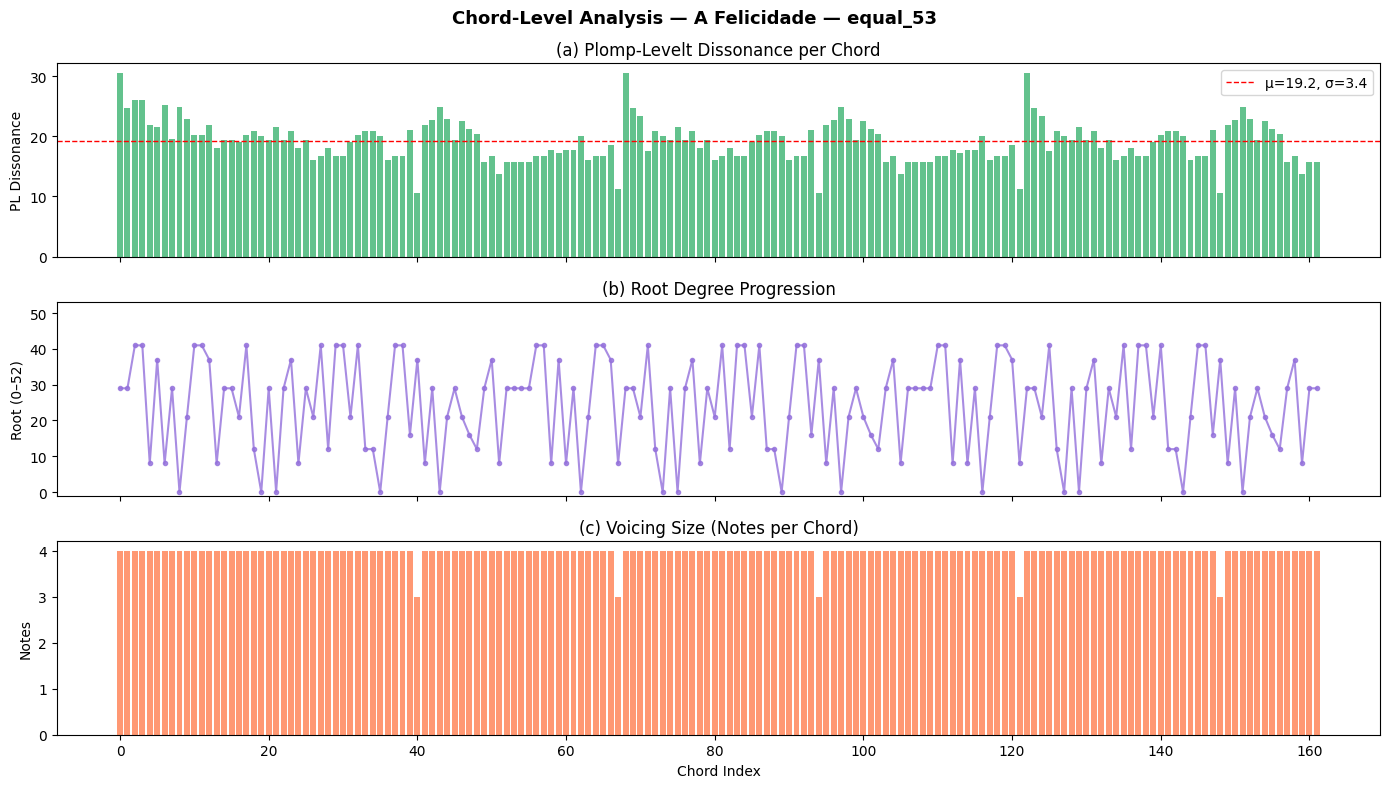

In [39]:
# ── Tokenize a specific song (change ID and pattern as needed) ───────────
toks = tokenize_song_by_id('13651', pattern=PATTERNS[0], max_chords=6)
if toks:
    alias = DatasetTokenizer.PATTERN_ALIASES.get(PATTERNS[0], PATTERNS[0])
    plot_song_analysis(toks, f'A Felicidade — {alias}')

In [40]:
# ── Compare tokenization across all patterns for the same song ───────────
for pat in PATTERNS:
    print()
    tokenize_song_by_id('13651', pattern=pat, max_chords=2)


═════════════════════════════════════════════════════════════════
  File:    53TET_13651_A Felicidade 1_G_minor.mid
  Pattern: equal_53 (8-8-5-8-8-9-7)
  Style:   STYLE_Bossa
  Chords:  162   Tokens: 1942
═════════════════════════════════════════════════════════════════

<START>
  STYLE_Bossa
  <CHORD_START>
    ROOT_29
    PATTERN_equal_53
    PL_30_6
    DUR_3840
      <MIDI_START> MPE_43_m2 MPE_46_m3 MPE_50_m1 MPE_53_m1 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_29
    PATTERN_equal_53
    PL_24_7
    DUR_3840
      <MIDI_START> MPE_43_m2 MPE_50_m1 MPE_53_m1 MPE_58_m3 <MIDI_END>
  <CHORD_END>
  ... (160 more chords)
<END>

═════════════════════════════════════════════════════════════════
  File:    53TET_13651_A Felicidade 1_G_minor.mid
  Pattern: meantone (8-8-6-8-8-8-7)
  Style:   STYLE_Bossa
  Chords:  162   Tokens: 1942
═════════════════════════════════════════════════════════════════

<START>
  STYLE_Bossa
  <CHORD_START>
    ROOT_30
    PATTERN_meantone
    PL_29_4
   

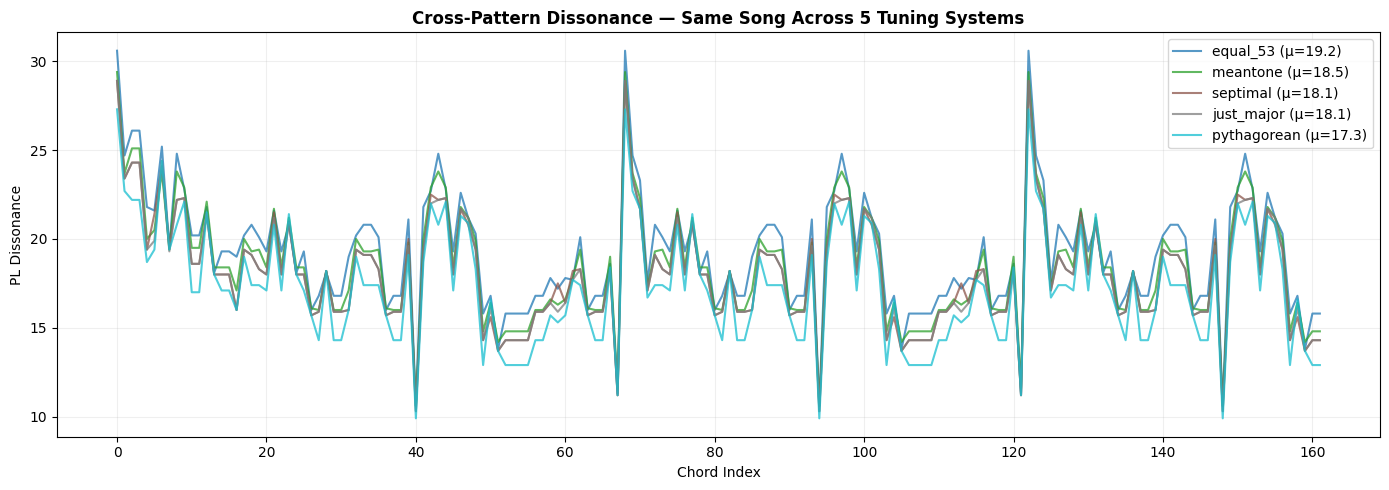

In [41]:
# ── Cross-pattern dissonance comparison ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(PATTERNS)))

for i, pat in enumerate(PATTERNS):
    t = tokenize_song_by_id('13651', pattern=pat, quiet=True)
    if t is None:
        continue
    chords = extract_chord_data(t)
    pl = [c['pl'] for c in chords]
    alias = DatasetTokenizer.PATTERN_ALIASES.get(pat, pat)
    ax.plot(pl, label=f'{alias} (μ={np.mean(pl):.1f})', color=colors[i], alpha=0.75, lw=1.5)

ax.set_xlabel('Chord Index')
ax.set_ylabel('PL Dissonance')
ax.set_title('Cross-Pattern Dissonance — Same Song Across 5 Tuning Systems', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7 — Vocabulary Summary

Breakdown of the vocabulary by token category.

In [42]:
# ── Vocabulary breakdown ─────────────────────────────────────────────────
categories = [
    ('Track',    lambda t: t in ('<START>', '<END>')),
    ('Style',    lambda t: t.startswith('STYLE_')),
    ('Chord',    lambda t: t.startswith('<CHORD')),
    ('ROOT',     lambda t: t.startswith('ROOT_')),
    ('PATTERN',  lambda t: t.startswith('PATTERN_')),
    ('PL',       lambda t: t.startswith('PL_')),
    ('DUR',      lambda t: t.startswith('DUR_')),
    ('MPE',      lambda t: t.startswith('MPE_')),
    ('MIDI',     lambda t: t.startswith('<MIDI')),
]

print(f"\n{'Category':>12s}  {'Unique':>6s}  Examples")
print(f"{'─'*12}  {'─'*6}  {'─'*45}")
for cat, pred in categories:
    toks = [t for t in stats['vocabulary'] if pred(t)]
    ex = ', '.join(toks[:4]) + (', ...' if len(toks) > 4 else '')
    print(f'{cat:>12s}  {len(toks):>6d}  {ex}')
print(f"{'TOTAL':>12s}  {stats['vocab_size']:>6d}")

# ── Storage efficiency ───────────────────────────────────────────────────
tok_bytes = (test_dir / 'tokens.npy').stat().st_size
off_bytes = (test_dir / 'offsets.npy').stat().st_size
voc_bytes = (test_dir / 'vocab.json').stat().st_size
print(f"\nStorage ({stats['total_songs']} songs):")
print(f"  tokens.npy  {tok_bytes/1024:>8.1f} KB  ({stats['total_tokens']:,} × int32)")
print(f"  offsets.npy {off_bytes/1024:>8.1f} KB  ({len(offsets):,} × int64)")
print(f"  vocab.json  {voc_bytes/1024:>8.1f} KB  ({stats['vocab_size']} entries)")
print(f"  Total:      {(tok_bytes + off_bytes + voc_bytes)/1024:>8.1f} KB")


    Category  Unique  Examples
────────────  ──────  ─────────────────────────────────────────────
       Track       2  <END>, <START>
       Style       1  STYLE_Samba
       Chord       2  <CHORD_END>, <CHORD_START>
        ROOT      31  ROOT_0, ROOT_12, ROOT_13, ROOT_16, ...
     PATTERN       5  PATTERN_equal_53, PATTERN_just_major, PATTERN_meantone, PATTERN_pythagorean, ...
          PL     136  PL_10_0, PL_10_1, PL_10_2, PL_10_3, ...
         DUR       3  DUR_1920, DUR_3840, DUR_960
         MPE      60  MPE_42_0, MPE_42_m1, MPE_43_0, MPE_43_m1, ...
        MIDI       2  <MIDI_END>, <MIDI_START>
       TOTAL     242

Storage (25 songs):
  tokens.npy      60.8 KB  (15,525 × int32)
  offsets.npy      0.3 KB  (26 × int64)
  vocab.json      10.0 KB  (242 entries)
  Total:          71.1 KB


## 8 — Decoder & Round-Trip Verification

Parse token IDs back to structured data; verify PL dissonance round-trip.

In [43]:
def decode_song(token_ids, id2tok) -> dict:
    """Decode a song's token IDs into structured data."""
    tokens = [id2tok[int(i)] for i in token_ids]
    song = {'style': None, 'chords': []}
    i = 0
    while i < len(tokens):
        t = tokens[i]
        if t.startswith('STYLE_'):
            song['style'] = t.replace('STYLE_', '')
        elif t == '<CHORD_START>':
            chord = {'root': None, 'pattern': None, 'pl': None, 'dur': None, 'mpe': []}
            i += 1
            while i < len(tokens) and tokens[i] != '<MIDI_START>':
                tk = tokens[i]
                if tk.startswith('ROOT_'):     chord['root'] = int(tk.split('_', 1)[1])
                elif tk.startswith('PATTERN_'): chord['pattern'] = tk.split('_', 1)[1]
                elif tk.startswith('PL_'):
                    p = tk.split('_'); chord['pl'] = float(f'{p[1]}.{p[2]}')
                elif tk.startswith('DUR_'):     chord['dur'] = int(tk.split('_', 1)[1])
                i += 1
            if i < len(tokens) and tokens[i] == '<MIDI_START>':
                i += 1
                while i < len(tokens) and tokens[i] != '<MIDI_END>':
                    if tokens[i].startswith('MPE_'):
                        p = tokens[i].split('_')
                        b = 0 if p[2] == '0' else (int(p[2][1:]) if p[2][0] == 'p' else -int(p[2][1:]))
                        chord['mpe'].append((int(p[1]), b))
                    i += 1
            while i < len(tokens) and tokens[i] in ('<MIDI_END>', '<CHORD_END>'):
                i += 1
            song['chords'].append(chord)
            continue
        i += 1
    return song

# ── Decode & display first song ──────────────────────────────────────────
s0 = decode_song(ids[offsets[0]:offsets[1]], id2tok)
print(f"Style: {s0['style']}  |  Chords: {len(s0['chords'])}\n")
for c in s0['chords'][:5]:
    notes = ', '.join(f'{m}{'+' if b >= 0 else ''}{b}' for m, b in c['mpe'])
    print(f"  ROOT={c['root']:>2d}  PAT={c['pattern']:<12s}  PL={c['pl']:>5.1f}  DUR={c['dur']:>4d}  [{notes}]")

# ── PL round-trip ────────────────────────────────────────────────────────
print(f"\nPL round-trip (first 10 chords):")
ok = 0
for c in s0['chords'][:10]:
    if c['mpe']:
        recomp = generate_dissonance_token(c['mpe'])
        orig   = f"PL_{str(c['pl']).replace('.', '_')}"
        m = '✓' if recomp == orig else '✗'
        if recomp == orig: ok += 1
        print(f"  {orig:<12s} → {recomp:<12s} {m}")
print(f"\n  {ok}/{min(10, len(s0['chords']))} match — {'round-trip OK' if ok == min(10, len(s0['chords'])) else 'some mismatches'}")

Style: Samba  |  Chords: 54

  ROOT= 0  PAT=equal_53      PL= 13.9  DUR=3840  [48+0, 51-1, 55-2]
  ROOT=33  PAT=equal_53      PL= 15.2  DUR=3840  [44-2, 48+0, 53-1]
  ROOT=37  PAT=equal_53      PL= 16.6  DUR=1920  [45-3, 48+0, 51-1]
  ROOT=29  PAT=equal_53      PL= 29.6  DUR=1920  [43-2, 47-3, 50-1, 53-1]
  ROOT= 0  PAT=equal_53      PL= 13.9  DUR=1920  [48+0, 51-1, 55-2]

PL round-trip (first 10 chords):
  PL_13_9      → PL_13_9      ✓
  PL_15_2      → PL_15_2      ✓
  PL_16_6      → PL_16_6      ✓
  PL_29_6      → PL_29_6      ✓
  PL_13_9      → PL_13_9      ✓
  PL_22_8      → PL_22_8      ✓
  PL_22_7      → PL_22_7      ✓
  PL_13_9      → PL_13_9      ✓
  PL_15_2      → PL_15_2      ✓
  PL_22_7      → PL_22_7      ✓

  10/10 match — round-trip OK


## 9 — Full Dataset Tokenization

Process all ~240k MIDI files → `tokens.npy` + `offsets.npy`.

> **Runtime**: ~30–60 min. Verify test results above first.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Full dataset tokenization — run when ready (~30–60 min)
# ══════════════════════════════════════════════════════════════════════════

full_dir   = OUTPUT_DIR / 'full'
full_stats = tokenizer.tokenize_dataset(full_dir)

print(f"Full dataset written to {full_dir}")
print(f"  Songs:  {full_stats['total_songs']:>10,}")
print(f"  Chords: {full_stats['total_chords']:>10,}")
print(f"  Tokens: {full_stats['total_tokens']:>10,}")
print(f"  Vocab:  {full_stats['vocab_size']:>10,}")
print(f"\n  tokens.npy  → {(full_dir / 'tokens.npy').stat().st_size / 1e6:.1f} MB")
print(f"  offsets.npy → {(full_dir / 'offsets.npy').stat().st_size / 1e3:.1f} KB")

[8-8-5-8-8-9-7]:   1%|          | 443/48062 [00:17<25:39, 30.93it/s]  

---

## Architecture Reference

### Encoded Token Stream (single song)
```
<START> STYLE_Jazz
  <CHORD_START> ROOT_0 PATTERN_pythagorean PL_18_4 DUR_960
    <MIDI_START> MPE_48_0 MPE_55_p1 MPE_60_0 MPE_64_m1 MPE_67_p2 <MIDI_END>
  <CHORD_END>
  <CHORD_START> ROOT_31 PATTERN_pythagorean PL_22_1 DUR_480
    <MIDI_START> MPE_55_p1 MPE_60_0 MPE_62_p2 MPE_67_0 <MIDI_END>
  <CHORD_END>
  ...
<END>
```

### Output Files
| File | Format | Content |
|------|--------|---------|
| `tokens.npy` | `int32` | Flat token-ID array (all songs concatenated) |
| `offsets.npy` | `int64` | `[0, len(song0), len(song0)+len(song1), ...]` |
| `vocab.json` | JSON | `{tok2id: {...}, id2tok: {...}}` |
| `stats.json` | JSON | Song/chord/token counts |

### Removed (Legacy) Tokens
| Token | Reason |
|-------|--------|
| `CH_<c>` | MPE implementation detail |
| `TIME_<t>` | Block chords are simultaneous |
| `NDUR_<d>` | All notes share `DUR_<d>` |
| `VOICING_<v>` | Encoded by MPE note list |
| Chord names | Lossy abstractions — root + MPE defines chord |